In [11]:
# Install required packages in the notebook environment
!pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud joblib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
#Download NLTK Resources
nltk.download('stopwords')
nltk.download('wordnet')    
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\satha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\satha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\satha\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [14]:
#Load Dataset
df = pd.read_csv(r'D:\Data Sets\amazon review.csv')


In [15]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [16]:
#Display Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [17]:
#columns in the dataset
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [18]:
df.shape

(568454, 10)

In [19]:
#Determine the polarity of each review using 
# in-built polarity_scores() method of nltk.sentiment.vader package
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
df['Polarity'] = df['Text'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [20]:
print(df['Polarity'].head())

0    0.9441
1   -0.5664
2    0.8265
3    0.0000
4    0.9468
Name: Polarity, dtype: float64


In [21]:
#Transform the 'overall' variable such that it represents 3 sentiment categories as follows:
#1<= Rating <3 , Category = 'Negative'
#Rating == 3 , Category = 'Neutral'
#Rating > 3 , Category = 'Positive'
def categorize_sentiment(score):
    if score < 3:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Score'].apply(categorize_sentiment)

In [22]:
df['Sentiment']

0         Positive
1         Negative
2         Positive
3         Negative
4         Positive
            ...   
568449    Positive
568450    Negative
568451    Positive
568452    Positive
568453    Positive
Name: Sentiment, Length: 568454, dtype: object

In [23]:
#Build a Decision Tree model to 
# predict the sentiment category given by the 
# user based on the text in the review.
# Prepare data for modeling
X = df['Text']
y = df['Sentiment']

print("Sentiment distribution:")
print(y.value_counts())

Sentiment distribution:
Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


In [24]:
# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_vect = vectorizer.fit_transform(X)

In [25]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_vect, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree classifier
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
# Evaluate
y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7983393584364638
Classification report:
              precision    recall  f1-score   support

    Negative       0.70      0.17      0.27     16407
     Neutral       0.65      0.01      0.02      8528
    Positive       0.80      0.99      0.89     88756

    accuracy                           0.80    113691
   macro avg       0.72      0.39      0.39    113691
weighted avg       0.78      0.80      0.73    113691

Confusion matrix:
[[ 2730    17 13660]
 [  409   101  8018]
 [  785    38 87933]]


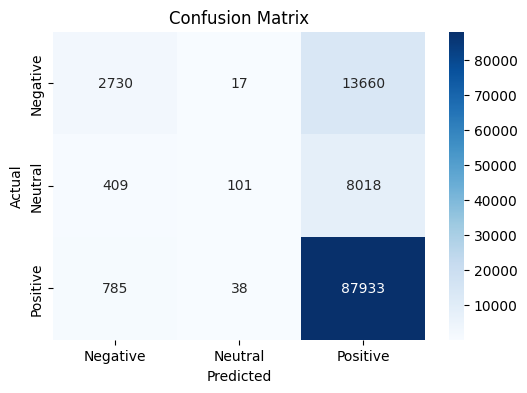

In [30]:
#visualize the confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [31]:
# Split into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_vect, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
#Build a Naive Bayes model to predict the sentiment category 
# given by the user based on the text in the review.
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()  
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)  

In [33]:
#evaluate Naive Bayes model
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))
print("Naive Bayes Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8161068158429428
Naive Bayes Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.27      0.41     16407
     Neutral       0.56      0.00      0.00      8528
    Positive       0.82      0.99      0.90     88756

    accuracy                           0.82    113691
   macro avg       0.74      0.42      0.44    113691
weighted avg       0.80      0.82      0.76    113691

Naive Bayes Confusion Matrix:
[[ 4487     8 11912]
 [  467    18  8043]
 [  471     6 88279]]


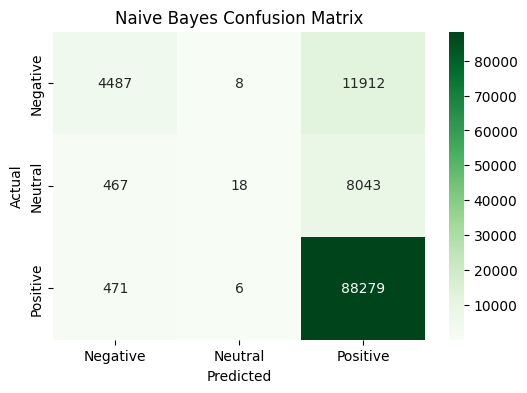

In [34]:
#Visualize the confusion matrix for Naive Bayes model
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Greens', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()